In [1]:
import torch
import torch.nn as nn
from transformers import WhisperModel, WhisperProcessor
import librosa
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
import time
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# FAST CONFIGURATION - Optimized for speed
CONFIG = {
    "data_usage": "subset",      # Keep as subset for speed
    "subset_ratio": 0.3,         # 30% of data
    "epochs": 5,                 # Reduced epochs
    "batch_size": 8,             # Smaller batches to avoid memory issues
    "learning_rate": 2e-4,       # Slightly higher for faster convergence
    "enable_plots": True,
    "save_results": True,
}

print("=== FAST Configuration ===")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Using device: cpu
=== FAST Configuration ===
  data_usage: subset
  subset_ratio: 0.3
  epochs: 5
  batch_size: 8
  learning_rate: 0.0002
  enable_plots: True
  save_results: True


In [3]:
# Simple data loader function (embedded for speed)
def load_dataset_fast():
    """Fast data loading - assumes CSV files already exist"""
    results_dir = 'results'
    train_csv = os.path.join(results_dir, 'train_data.csv')
    test_csv = os.path.join(results_dir, 'test_data.csv')
    
    if not os.path.exists(train_csv):
        raise FileNotFoundError(f"Train CSV not found. Run data_loader.ipynb first!")
    
    print("Loading data from existing CSV files...")
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    
    return train_df, test_df

In [4]:
class FastDysarthriaDataset(Dataset):
    def __init__(self, audio_paths, labels, processor):
        self.audio_paths = audio_paths
        self.labels = labels
        self.processor = processor
        self.sampling_rate = 16000
        
    def __len__(self):
        return len(self.audio_paths)
    
    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load audio
            audio, sr = librosa.load(audio_path, sr=self.sampling_rate, mono=True)
            
            # Process with forced padding to 30 seconds (3000 frames)
            inputs = self.processor(
                audio, 
                sampling_rate=self.sampling_rate,
                return_tensors="pt",
                padding="max_length",  # Force padding to max length
                max_length=30 * self.sampling_rate,  # 30 seconds
                truncation=True,
                return_attention_mask=True
            )
            
            return inputs.input_features.squeeze(), torch.tensor(label, dtype=torch.long)
            
        except Exception as e:
            print(f"Error loading {audio_path}: {e}")
            # Return zeros with correct shape for Whisper (80, 3000)
            inputs = self.processor(
                np.zeros(30 * self.sampling_rate),
                sampling_rate=self.sampling_rate,
                return_tensors="pt",
                padding="max_length",
                max_length=30 * self.sampling_rate,
                truncation=True
            )
            return inputs.input_features.squeeze(), torch.tensor(label, dtype=torch.long)

# Also add a custom collate function to handle the batching properly
def collate_fn(batch):
    """Custom collate function to ensure consistent tensor shapes"""
    features, labels = zip(*batch)
    
    # Stack features and ensure they have the same shape
    features_stacked = []
    for feat in features:
        # Ensure shape is (80, 3000)
        if feat.shape[-1] < 3000:
            # Pad if shorter
            pad_size = 3000 - feat.shape[-1]
            feat = torch.nn.functional.pad(feat, (0, pad_size))
        elif feat.shape[-1] > 3000:
            # Truncate if longer
            feat = feat[:, :3000]
        features_stacked.append(feat)
    
    features_batch = torch.stack(features_stacked)
    labels_batch = torch.stack(labels)
    
    return features_batch, labels_batch

In [5]:
class FastWhisperClassifier(nn.Module):
    def __init__(self, num_classes=5, model_name="openai/whisper-tiny"):
        super().__init__()
        
        # Load Whisper - keep encoder frozen for speed
        self.whisper = WhisperModel.from_pretrained(model_name)
        self.processor = WhisperProcessor.from_pretrained(model_name)
        
        # Freeze encoder
        for param in self.whisper.encoder.parameters():
            param.requires_grad = False
        
        # Simple classifier
        hidden_size = self.whisper.config.d_model
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
        print(f"Model initialized with {sum(p.numel() for p in self.parameters()):,} parameters")
        print(f"Trainable parameters: {sum(p.numel() for p in self.parameters() if p.requires_grad):,}")
        
    def forward(self, input_features):
        # Whisper encoder expects input_features of shape (batch, 80, 3000)
        outputs = self.whisper.encoder(input_features)
        hidden_states = outputs.last_hidden_state
        
        # Mean pooling (faster than attention)
        pooled = hidden_states.mean(dim=1)
        
        # Classification
        logits = self.classifier(pooled)
        return logits

In [6]:
def load_and_prepare_data_fast():
    """Fast data preparation"""
    train_df, test_df = load_dataset_fast()
    
    print(f"Train samples: {len(train_df)}")
    print(f"Test samples: {len(test_df)}")
    print(f"Class distribution: {train_df['class'].value_counts().sort_index()}")
    
    # Simple class mapping
    def map_class(label):
        return int(float(label)) - 1
    
    y_train = train_df['class'].apply(map_class).values
    X_train = train_df['file_path'].values
    
    # Apply subset
    if CONFIG["data_usage"] == "subset":
        from sklearn.utils import resample
        X_train, y_train = resample(X_train, y_train, 
                                  n_samples=int(len(X_train) * CONFIG["subset_ratio"]),
                                  random_state=42,
                                  stratify=y_train)
    
    # Simple split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
    )
    
    print(f"Final split - Train: {len(X_train)}, Val: {len(X_val)}")
    print(f"Labels - Train: {np.bincount(y_train)}, Val: {np.bincount(y_val)}")
    
    return X_train, X_val, y_train, y_val, test_df

In [7]:
def train_fast(model, train_loader, val_loader):
    """Fast training without fancy features"""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    val_accuracies = []
    
    print(f"Fast training for {CONFIG['epochs']} epochs...")
    start_time = time.time()
    
    for epoch in range(CONFIG["epochs"]):
        # Training
        model.train()
        total_loss = 0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            # Ensure correct shape for Whisper (batch, 80, 3000)
            if data.dim() == 2:
                data = data.unsqueeze(0)  # Add batch dimension if needed
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                if data.dim() == 2:
                    data = data.unsqueeze(0)
                outputs = model(data)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
        
        val_accuracy = correct / total
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}: Loss: {avg_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time/60:.2f} minutes")
    
    return train_losses, val_accuracies

In [8]:
def main_fast():
    try:
        # Load data quickly
        print("=== Fast Data Loading ===")
        X_train, X_val, y_train, y_val, test_df = load_and_prepare_data_fast()
        
        # Initialize model
        print("\n=== Initializing Fast Model ===")
        model = FastWhisperClassifier(num_classes=5)
        
        # Create datasets
        train_dataset = FastDysarthriaDataset(X_train, y_train, model.processor)
        val_dataset = FastDysarthriaDataset(X_val, y_val, model.processor)
        
        # Data loaders
        train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, collate_fn=collate_fn)
        
        print(f"Data loaded: {len(train_loader)} train batches, {len(val_loader)} val batches")

        # Test one batch to verify shapes
        print("\nTesting data shapes...")
        for data, targets in train_loader:
            print(f"Input features shape: {data.shape}")  # Should be (batch, 80, 3000)
            print(f"Targets shape: {targets.shape}")
            break
        
        # Train
        print("\n=== Training ===")
        train_losses, val_accuracies = train_fast(model, train_loader, val_loader)
        
        # Quick evaluation on validation set
        model.eval()
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                if data.dim() == 2:
                    data = data.unsqueeze(0)
                outputs = model(data)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        
        accuracy = accuracy_score(all_targets, all_preds)
        f1 = f1_score(all_targets, all_preds, average='macro')
        
        # Results
        print(f"\n" + "="*50)
        print("RESULTS - Whisper-tiny")
        print("="*50)
        print(f"Validation Accuracy: {accuracy:.4f}")
        print(f"Validation Macro F1: {f1:.4f}")
        
        # Quick classification report
        target_names = ['Severe (1)', 'Moderate (2)', 'Mild (3)', 'No dysarthria (4)', 'Healthy (5)']
        print(f"\nClassification Report:")
        print(classification_report(all_targets, all_preds, 
                                  target_names=target_names,
                                  digits=3))
        
        # Confusion matrix
        cm = confusion_matrix(all_targets, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        plt.title('Confusion Matrix - Whisper-tiny')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('plots/whisper_tiny_confusion_matrix.pdf', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Training history
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, 'b-')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.subplot(1, 2, 2)
        plt.plot(val_accuracies, 'g-')
        plt.title('Validation Accuracy')
        plt.xlabel('Epoch')
        plt.tight_layout()
        plt.savefig('plots/whisper_tiny_training_history.pdf', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save results
        if CONFIG["save_results"]:
            results_df = pd.DataFrame({
                'Model': ['Fast Whisper-tiny'],
                'Accuracy': [accuracy],
                'Macro_F1': [f1],
                'Epochs': [CONFIG["epochs"]],
                'Batch_Size': [CONFIG["batch_size"]],
                'Notes': ['Optimized for speed - uses full 30s Whisper processing']
            })
            
            os.makedirs('results', exist_ok=True)
            results_df.to_csv('results/whisper_metrics.csv', index=False)
            print("Results saved to results/whisper_metrics.csv")
        
        return model, accuracy, f1
        
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        return None, 0, 0

FAST Whisper-tiny Model - Fixed Version
=== Fast Data Loading ===
Loading data from existing CSV files...
Train samples: 2176
Test samples: 784
Class distribution: class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64
Final split - Train: 456, Val: 196
Labels - Train: [ 10  43  96 127 180], Val: [ 4 19 41 55 77]

=== Initializing Fast Model ===
Model initialized with 37,810,565 parameters
Trainable parameters: 29,602,181
Data loaded: 57 train batches, 25 val batches

Testing data shapes...
Input features shape: torch.Size([8, 80, 3000])
Targets shape: torch.Size([8])

=== Training ===
Fast training for 5 epochs...
Epoch 1, Batch 0, Loss: 1.7304
Epoch 1, Batch 10, Loss: 1.5452
Epoch 1, Batch 20, Loss: 1.4792
Epoch 1, Batch 30, Loss: 1.3112
Epoch 1, Batch 40, Loss: 1.0856
Epoch 1, Batch 50, Loss: 0.9993
Epoch 1: Loss: 1.4326, Val Acc: 0.3929
Epoch 2, Batch 0, Loss: 1.4906
Epoch 2, Batch 10, Loss: 1.4317
Epoch 2, Batch 20, Loss: 1.3869
Epoch 2, Batch 30, Loss: 1.072

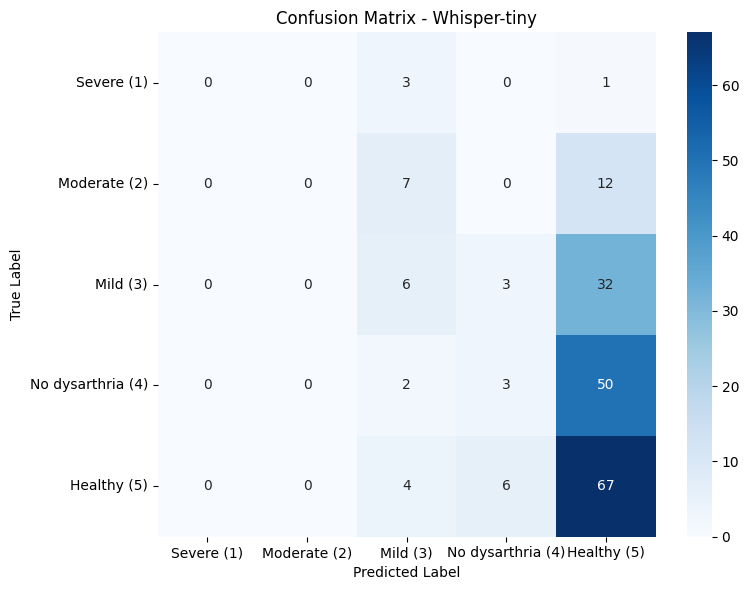

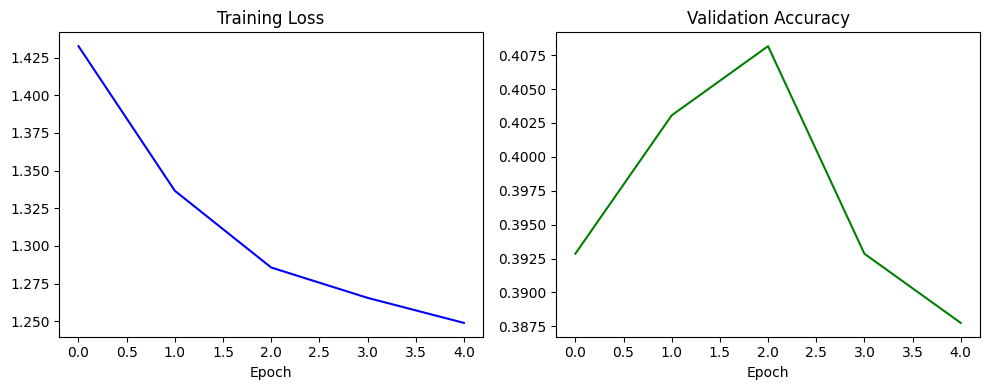

Results saved to results/whisper_metrics.csv

FAST TRAINING COMPLETED!
Model: Fast Whisper-tiny
Accuracy: 0.3878
F1-Score: 0.1681


In [9]:
if __name__ == "__main__":
    print("FAST Whisper-tiny Model - Fixed Version")
    print("=" * 55)
    
    # Make sure data exists first
    if not os.path.exists('results/train_data.csv'):
        print("Please run data_loader.ipynb first to create CSV files!")
        print("Run this in Jupyter: %run data_loader.ipynb")
    else:
        model, accuracy, f1 = main_fast()
        
        if model is not None:
            print(f"\nFAST TRAINING COMPLETED!")
            print(f"Model: Fast Whisper-tiny")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1-Score: {f1:.4f}")
        else:
            print("\nTraining failed")